# Shark Attack

Objective: Identify the safest conditions to open a surf school in Brazil by analyzing shark attack patterns.

In [1]:
import pandas as pd

import xlrd

workbook = pd.read_excel("GSAF5.xls")

In [2]:
workbook 

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,...,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,...,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,...,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,...,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,...,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


## Phase 1 – Data Familiarization

Initial exploration of the dataset to understand its structure and identify potential data quality issues.

The dataset contains historical records of shark attacks, including information such as location, activity, age, gender, injury details, and date of the incident.

At first glance, the dataset appears to be unstructured and contains inconsistencies, missing values, and non-standardized text fields, which makes data cleaning a necessary step before analysis.

In [3]:
workbook.head() # Initial exploration of the dataset

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,...,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,...,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,...,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,...,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,...,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After an initial exploration of the dataset, we identified several key columns relevant for our analysis:

-Country: Location of the incident
-Activity: What the person was doing
-Age: Age of the victim
-Sex: Gender of the victim
-Date: When the attack occurred
-Injury: Description of the outcome
-Species: Type of shark involved (when available)

In [4]:
workbook.info() # We observe missing values and inconsistent formats

<class 'pandas.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7082 non-null   object 
 1   Year            7080 non-null   float64
 2   Type            7064 non-null   str    
 3   Country         7032 non-null   str    
 4   State           6595 non-null   str    
 5   Location        6515 non-null   str    
 6   Activity        6499 non-null   str    
 7   Name            6864 non-null   str    
 8   Sex             6504 non-null   str    
 9   Age             4088 non-null   object 
 10  Injury          7047 non-null   str    
 11  Fatal Y/N       6521 non-null   object 
 12  Time            3555 non-null   object 
 13  Species         3951 non-null   str    
 14  Source          7062 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   str    
 17  href            6796 non-null   str    
 18 

Several data quality issues were identified:

Missing values in key columns such as Age, Activity, and Country
Inconsistent text formatting, especially in the Activity column (e.g., "surf", "surfing", "surfboard")
Unstructured text fields in columns like Injury and Species
Inconsistent date formats, making time-based analysis difficult
Potential duplicate records

These issues must be addressed before performing any reliable analysis.

## Phase 2 – Data Cleaning & Transformation



In [5]:
workbook.columns=workbook.columns.str.strip()
print(workbook)

               Date    Year        Type             Country  \
0        18th March  2026.0  Unprovoked                 USA   
1        14th March  2026.0  Unprovoked           Australia   
2        10th March  2026.0  Unprovoked           Australia   
3         5th March  2026.0  Unprovoked           Australia   
4     22nd February  2026.0  Unprovoked       New Caledonia   
...             ...     ...         ...                 ...   
7077    Before 1903     0.0  Unprovoked           AUSTRALIA   
7078    Before 1903     0.0  Unprovoked           AUSTRALIA   
7079      1900-1905     0.0  Unprovoked                 USA   
7080      1883-1889     0.0  Unprovoked              PANAMA   
7081      1845-1853     0.0  Unprovoked  CEYLON (SRI LANKA)   

                  State                             Location       Activity  \
0            California     Big River Beach Mendocino County        Surfing   
1     Western Australia                              Exmouth       Swimming   
2     

In [6]:
workbook.isnull().sum()

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              35
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                283
href formula       288
href               286
Case Number        284
Case Number.1      285
original order     283
Unnamed: 21       7081
Unnamed: 22       7080
dtype: int64

In [7]:
workbook = workbook.drop(columns=[
    "Unnamed: 21", "Unnamed: 22",
    "href", "href formula", "pdf",
    "Case Number.1"
], errors="ignore")
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN,"The Sun, 10/20/1938",ND.0002,3.0


In [8]:
#Remove columns where more than 50% of values are missing
workbook = workbook.dropna(axis=1, thresh=len(workbook) * 0.5)#keeps columns only with enough data
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN,"The Sun, 10/20/1938",ND.0002,3.0


In [9]:
# Remove any remaining unnamed columns
workbook = workbook.loc[:, ~workbook.columns.str.contains("^Unnamed")]
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN,"The Sun, 10/20/1938",ND.0002,3.0


In [10]:
#Remove duplicate rows
workbook = workbook.drop_duplicates()
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN,"The Sun, 10/20/1938",ND.0002,3.0


In [11]:
#Handles missing values
workbook = workbook.fillna({
    "Country": "Unknown",
    "State": "Unknown",
    "Location": "Unknown",
    "Activity": "Unknown",
    "Sex": "Unknown",
    "Age": "Unknown",
    "Fatal Y/N": "Unknown",
    "Species": "Unknown"
})
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0


In [12]:
#manipulating strings
workbook["Sex"] = workbook["Sex"].str.upper().str.strip()
workbook["Fatal Y/N"] = workbook["Fatal Y/N"].str.upper().str.strip()
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0


In [13]:
#manipulating strings
workbook["Sex"] = workbook["Sex"].str.upper().str.strip()
workbook["Fatal Y/N"] = workbook["Fatal Y/N"].str.upper().str.strip()
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0


In [14]:
#Extract Age 
workbook["Age_clean"] = workbook["Age"].str.extract(r"(\d+)")
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order,Age_clean
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,39
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,50
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0,NaN
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0,NaN
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0,NaN
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0,NaN


In [15]:
#Data cleaning in Date format
workbook["Date_clean"] = workbook["Date"].str.replace(
    r"(\d+)(st|nd|rd|th)", r"\1", regex=True
)
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order,Age_clean,Date_clean
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,39,18 March
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,14 March
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,10 March
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,50,5 March
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,55,22 February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0,NaN,Before 1903
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0,NaN,Before 1903
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0,NaN,1900-1905
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0,NaN,1883-1889


In [16]:
#standartize Activity
workbook["Activity_group"] = workbook["Activity"].str.lower().apply(
    lambda x: "Swimming" if "swim" in x else
              "Surfing" if "surf" in x else
              "Fishing" if "fish" in x else
              "Diving" if "dive" in x else
              "Other"
)
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,39,18 March,Surfing
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,14 March,Swimming
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,10 March,Other
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,50,5 March,Other
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,55,22 February,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0,NaN,Before 1903,Other
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0,NaN,Before 1903,Other
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0,NaN,1900-1905,Swimming
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0,NaN,1883-1889,Other


In [17]:
#standardize location
import re
workbook["Location"] = workbook["Location"].str.replace(r"Off|Near", "", regex=True, flags=re.IGNORECASE).str.strip()
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,Injuries to both legs and feet,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,39,18 March,Surfing
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,Minor injuries,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,14 March,Swimming
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,None reported damage to board,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,10 March,Other
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,Lacerations elbow and abdomen,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,50,5 March,Other
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata Point Magnin,Wing Foiling,Cyril Chevalier,M,55,Deep wounds arms and legs,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,55,22 February,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0,NaN,Before 1903,Other
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,FATAL,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0,NaN,Before 1903,Other
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,FATAL,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0,NaN,1900-1905,Swimming
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,FATAL,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0,NaN,1883-1889,Other


In [18]:
print(workbook["Location"].head(10))

0         Big River Beach Mendocino County
1                                  Exmouth
2                                  Exmouth
3                      Lady Elliott Island
4                  Anse Vata  Point Magnin
5                            Caribbean Sea
6               Del Chifre Beach in Olinda
7                Angels Beach East Ballina
8               Cooee Beach west of Burnie
9    Point Plomber North of Port Macquarie
Name: Location, dtype: str


In [19]:
# Remove 'st', 'nd', 'rd', 'th'
workbook["Date"] = workbook["Date"].astype(str).str.replace(r'(\d+)(st|nd|rd|th)', r'\1', regex=True)

# Combine with Year column
workbook["Date_str"] = workbook["Date"] + " " + workbook["Year"].astype("Int64").astype(str)
workbook

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Fatal Y/N,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group,Date_str
0,18 March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,...,N,1715hrs,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,39,18 March,Surfing,18 March 2026
1,14 March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,...,N,1015hrs,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,14 March,Swimming,14 March 2026
2,10 March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,...,N,0800hrs,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,10 March,Other,10 March 2026
3,5 March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,...,N,0815hrs,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,50,5 March,Other,5 March 2026
4,22 February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata Point Magnin,Wing Foiling,Cyril Chevalier,M,55,...,Y,?,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,55,22 February,Other,22 February 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,Unknown,...,Y,NaN,Unknown,"H. Taunton; N. Bartlett, p. 234",ND.0005,6.0,NaN,Before 1903,Other,Before 1903 0
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Unknown,Pearl diving,Ahmun,M,Unknown,...,Y,NaN,Unknown,"H. Taunton; N. Bartlett, pp. 233-234",ND.0004,5.0,NaN,Before 1903,Other,Before 1903 0
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,Unknown,...,Y,NaN,Unknown,"F. Schwartz, p.23; C. Creswell, GSAF",ND.0003,4.0,NaN,1900-1905,Swimming,1900-1905 0
7080,1883-1889,0.0,Unprovoked,PANAMA,Unknown,"Panama Bay 8ºN, 79ºW",Unknown,Jules Patterson,M,Unknown,...,Y,NaN,Unknown,"The Sun, 10/20/1938",ND.0002,3.0,NaN,1883-1889,Other,1883-1889 0


In [20]:
df = workbook

In [24]:
df['Country'].unique() 

<StringArray>
[                     'Usa',                'Australia',
            'New Caledonia',           'Cayman Islands',
                   'Brazil',        'Us Virgin Islands',
               'Mozambique',         'French Polynesia',
                    'Samoa',                 'Columbia',
 ...
        'Mediterranean Sea',                   'Sweden',
                   'Roatan', 'Between Portugal & India',
                 'Djibouti',                  'Bahrein',
                    'Korea',                 'Red Sea?',
                    'Asia?',       'Ceylon (Sri Lanka)']
Length: 214, dtype: str

In [27]:
df['Country_clean'] = df['Country'].str.strip().str.title()

In [28]:
'Portugal' in df['Country_clean'].values

True

In [29]:
df[df['Country_clean'] == 'Portugal']

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group,Date_str,Country_clean
180,16 Aug-2023,2023.0,Provoked,Portugal,Norte,9 nm Vila do Conde,Fishing,male,M,Unknown,...,19h30,Blue shark,"Portugese Resident, 8/17/2023",NaN,NaN,NaN,16 Aug-2023,Fishing,16 Aug-2023 2023,Portugal
3842,05-Dec-1979,1979.0,Invalid,Portugal,Madeira Islands,"Sao Jorge, Madeira Island",Spearfishing,Fernando Branco de Abreu,M,19,...,NaN,White shark?,C. Moore. GSAF,1979.12.00,3236.0,19,05-Dec-1979,Fishing,05-Dec-1979 1979,Portugal
5014,22-Jun-1956,1956.0,Watercraft,Portugal,Madeira,Funchal,Longling fishing,Manuel Pereira,M,23,...,NaN,Unknown,"C. Moore, GSAF",1956.06.22,2064.0,23,22-Jun-1956,Fishing,22-Jun-1956 1956,Portugal
5436,Jul-1943,1943.0,Watercraft,Portugal,Unknown,Sines,Fishing for mackerel,rowboats attacked by sharks,UNKNOWN,Unknown,...,NaN,Unknown,Letter dated 8/31/1959 from A. Cordeiro,1943.07.00.b,1642.0,NaN,Jul-1943,Fishing,Jul-1943 1943,Portugal


In [33]:
df_surf = df[df['Activity_group'] == 'Surfing']

In [34]:
df_surf['Country_clean'].value_counts().head(10)

Country_clean
Usa                 817
Australia           324
South Africa        143
Brazil               40
Reunion              21
New Zealand          19
Mexico               12
New Caledonia         8
Indonesia             7
French Polynesia      5
Name: count, dtype: int64

Brazil represents a high-demand surf market with moderate shark incident levels, likely driven by high participation rates. In contrast, Portugal shows minimal recorded surf-related shark incidents, making it a potentially safer and more strategic location for a surf school focused on risk-conscious customers.”

In [36]:
df_brazil_surf = df[
    (df['Country_clean'] == 'Brazil') & 
    (df['Activity_group'] == 'Surfing')
] 
df_brazil_surf.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group,Date_str,Country_clean
236,21-Feb-2023,2023.0,Unprovoked,Brazil,Pernambuco,Praia de Milagres,Surfing,André Luiz Gomes da Silva,M,32,...,16h30,Unknown,"Globo, 2/21/2023",NaN,NaN,32,21-Feb-2023,Surfing,21-Feb-2023 2023,Brazil
449,13-Jan-2021,2021.0,Unprovoked,Brazil,Pernambuco,Cacimba do Padre Beach,Surfing,Sergo Noronha,M,52,...,NaN,Unknown,"K. McMurray, TrackingSharks.com",2021.01.13.b,6624.0,NaN,13-Jan-2021,Surfing,13-Jan-2021 2021,Brazil
662,14-Feb-2019,2019.0,Unprovoked,Brazil,Fernando de Noronha,Cacimba do Padre,Surfing,Carlos Vinícius de Oliveira,M,31,...,17h30,Lemon shark,"K. McMurray, TrackingSharks.com",2019.02.14,6412.0,NaN,14-Feb-2019,Surfing,14-Feb-2019 2019,Brazil
794,12-Jan-2018,2018.0,Unprovoked,Brazil,Fernando de Noronha,Conceicao Beach,Surfing,Ricardo Ferrari Bulhoes,M,20,...,Late afternoon,small shark,TrackingSharks.com,2018.01.12,6281.0,NaN,12-Jan-2018,Surfing,12-Jan-2018 2018,Brazil
1189,31-Mar-2015,2015.0,Invalid,Brazil,Pernambuco,"Praia del Chifre, Olinda",Surfing,Diego Gomes Mota,M,23,...,11h00,No shark involvement,"Globo, 3/31/2015",2015.03.31,5890.0,23,31-Mar-2015,Surfing,31-Mar-2015 2015,Brazil


In [39]:
df[df['Country'].str.contains('bra', case=False, na=False)].shape[0]

123

The majority of shark incidents in Brazil are not related to surfing activities

In [40]:
df[df['Country_clean'] == 'Brazil']

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group,Date_str,Country_clean
6,29 January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,13,29 January,Swimming,29 January 2026,Brazil
233,06-Mar-2023,2023.0,Unprovoked,Brazil,Pernambuco,Piedade Beach,Swimming,Kaylane Timóteo Freitas,F,15,...,14h20,Unknown,"JC, 3/6/2023",NaN,NaN,15,06-Mar-2023,Swimming,06-Mar-2023 2023,Brazil
234,05-Mar-2023,2023.0,Unprovoked,Brazil,Pernambuco,Piedade Beach,Swimming,male,M,14,...,NaN,Unknown,"JC, 3/6/2023",NaN,NaN,14,05-Mar-2023,Swimming,05-Mar-2023 2023,Brazil
236,21-Feb-2023,2023.0,Unprovoked,Brazil,Pernambuco,Praia de Milagres,Surfing,André Luiz Gomes da Silva,M,32,...,16h30,Unknown,"Globo, 2/21/2023",NaN,NaN,32,21-Feb-2023,Surfing,21-Feb-2023 2023,Brazil
354,15-Nov-2021,2021.0,Unprovoked,Brazil,São Paulo.,Boqueirão Beach,Playing,male,M,11,...,12h00,dogfish,"K. McMurray, TrackingSharks.com",2021.11.15,6718.0,NaN,15-Nov-2021,Other,15-Nov-2021 2021,Brazil
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5889,25-Oct-1927,1927.0,Sea Disaster,Brazil,Porto Seguro,90 miles Albrohos Island,Italian liner Principessa Mafalda sank,NaN,UNKNOWN,Unknown,...,12h00,Unknown,"L. Schultz & M. Malin, p.557; SAF Case #833",1927.10.25,1190.0,NaN,25-Oct-1927,Other,25-Oct-1927 1927,Brazil
6515,20-Jan-1887,1887.0,Sea Disaster,Brazil,Alagoas,Maceió,The passenger ship Kapuna was run down the ore...,Whittle,M,Unknown,...,03h00,Unknown,"Brisbane Courier, 4/14/1887",1887.01.20,564.0,NaN,20-Jan-1887,Other,20-Jan-1887 1887,Brazil
6547,Reported 28-Apr-1884,1884.0,Unprovoked,Brazil,Unknown,Bahia,Fell overboard from the steamship Chala,male,M,Unknown,...,NaN,Unknown,"Pittsburgh Post Gazette, 4/28/1884",1884.04.28.R,532.0,NaN,Reported 28-Apr-1884,Other,Reported 28-Apr-1884 1884,Brazil
6618,02-Feb-1878,1878.0,Sea Disaster,Brazil,Unknown,Unknown,Washed off raft,escaped convict,M,Unknown,...,NaN,Unknown,"St Louis Post Dispatch, 5/22/1878",1878.02.02,461.0,NaN,02-Feb-1878,Other,02-Feb-1878 1878,Brazil


In [41]:
df_brazil_surf

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Time,Species,Source,Case Number,original order,Age_clean,Date_clean,Activity_group,Date_str,Country_clean
236,21-Feb-2023,2023.0,Unprovoked,Brazil,Pernambuco,Praia de Milagres,Surfing,André Luiz Gomes da Silva,M,32,...,16h30,Unknown,"Globo, 2/21/2023",NaN,NaN,32,21-Feb-2023,Surfing,21-Feb-2023 2023,Brazil
449,13-Jan-2021,2021.0,Unprovoked,Brazil,Pernambuco,Cacimba do Padre Beach,Surfing,Sergo Noronha,M,52,...,NaN,Unknown,"K. McMurray, TrackingSharks.com",2021.01.13.b,6624.0,NaN,13-Jan-2021,Surfing,13-Jan-2021 2021,Brazil
662,14-Feb-2019,2019.0,Unprovoked,Brazil,Fernando de Noronha,Cacimba do Padre,Surfing,Carlos Vinícius de Oliveira,M,31,...,17h30,Lemon shark,"K. McMurray, TrackingSharks.com",2019.02.14,6412.0,NaN,14-Feb-2019,Surfing,14-Feb-2019 2019,Brazil
794,12-Jan-2018,2018.0,Unprovoked,Brazil,Fernando de Noronha,Conceicao Beach,Surfing,Ricardo Ferrari Bulhoes,M,20,...,Late afternoon,small shark,TrackingSharks.com,2018.01.12,6281.0,NaN,12-Jan-2018,Surfing,12-Jan-2018 2018,Brazil
1189,31-Mar-2015,2015.0,Invalid,Brazil,Pernambuco,"Praia del Chifre, Olinda",Surfing,Diego Gomes Mota,M,23,...,11h00,No shark involvement,"Globo, 3/31/2015",2015.03.31,5890.0,23,31-Mar-2015,Surfing,31-Mar-2015 2015,Brazil
1595,12-Nov-2011,2011.0,Unprovoked,Brazil,Pernambuco,"Punta Del Chifre Beach, Olinda",Surfing,Jerônimo Pereira da Paz,M,35,...,NaN,Unknown,"H. Nickel & A. Brenneka, SharkAttackSurvivors.com",2011.11.12,5483.0,35,12-Nov-2011,Surfing,12-Nov-2011 2011,Brazil
1653,29-Jun-2011,2011.0,Unprovoked,Brazil,Pernambuco,Praia do Pina,Surfing,Malisson Lima,M,21,...,10h00,Unknown,"USA Today, 6/29/2011",2011.06.29,5425.0,21,29-Jun-2011,Surfing,29-Jun-2011 2011,Brazil
1797,31-Jan-2010,2010.0,Unprovoked,Brazil,Rio Grande Do Sul,"Atlantis Beach, Tramandai",Surfing,Andrei Johann,M,29,...,NaN,Thought to involve a juvenile hammerhead shark,"C. Eksander, GSAF",2010.01.30,5281.0,29,31-Jan-2010,Surfing,31-Jan-2010 2010,Brazil
1996,24-Jun-2008,2008.0,Unprovoked,Brazil,Bahia,Guarajuba,Surfing,Ricardo Garcia Santo Sé,M,Unknown,...,Morning,Unknown,"O Globo, 6/25/2008",2008.06.24,5082.0,NaN,24-Jun-2008,Surfing,24-Jun-2008 2008,Brazil
1999,11-Jun-2008,2008.0,Unprovoked,Brazil,Pernambuco,"Punta Del Chifre, Olinda",Surfing,Juan Rodrigues Galvao,M,14,...,NaN,Unknown,"O Globo, 6/12/2008",2008.06.11,5079.0,14,11-Jun-2008,Surfing,11-Jun-2008 2008,Brazil


In [43]:
df_brazil_surf['Date'] = pd.to_datetime(df_brazil_surf['Date'], errors='coerce')

In [44]:
df_brazil_surf = df_brazil_surf.copy()
df_brazil_surf['Date'] = pd.to_datetime(df_brazil_surf['Date'], errors='coerce')

In [45]:
df_brazil_surf['Month'] = df_brazil_surf['Date'].dt.month
df_brazil_surf['Month'].value_counts().sort_index()

Month
1     4
2     3
3     3
4     2
5     3
6     3
7     9
8     1
10    5
11    2
12    5
Name: count, dtype: int64

In [46]:
df_brazil_surf['Date'].isna().sum()

np.int64(0)

In [48]:
df['Age_clean'] = df['Age'].fillna('Unknown')

In [51]:
df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species',
       'Source', 'Case Number', 'original order', 'Age_clean', 'Date_clean',
       'Activity_group', 'Date_str', 'Country_clean'],
      dtype='str')

In [52]:
df = df.drop(columns=['Source', 'pdf', 'href'], errors='ignore')

## Phase 3 – Structuring & Exploratory Data Analysis (EDA)


In [55]:
!pip install matplotlib

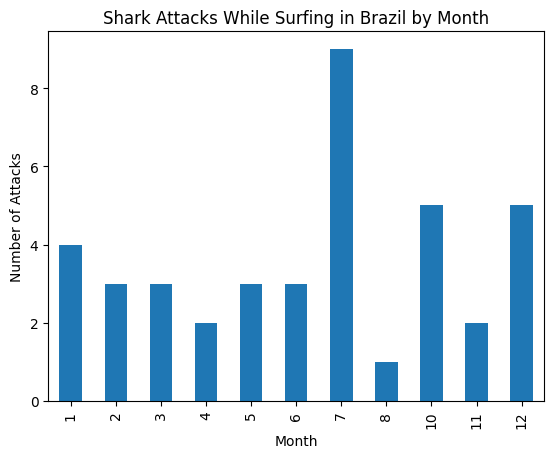

In [57]:
import matplotlib.pyplot as plt

df_brazil_surf['Month'].value_counts().sort_index().plot(kind='bar')
plt.title('Shark Attacks While Surfing in Brazil by Month')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.show()

Surfing-related shark attacks in Brazil show seasonal patterns, with peaks in July and late-year months.
Brazil presents a moderate number of surf-related shark attacks compared to global hotspots.

In [66]:
df['Activity_group'].value_counts()

Activity_group
Other       3024
Surfing     1445
Fishing     1312
Swimming    1281
Diving        20
Name: count, dtype: int64

Surfing is one of the most common activities associated with shark attacks globally.

In [67]:
df_brazil_surf['State'].value_counts()

State
Pernambuco             32
Fernando de Noronha     2
Bahia                   2
Maranhão                2
Rio Grande Do Sul       1
Rio de Janeiro          1
Name: count, dtype: int64

Shark attacks are highly concentrated in Pernambuco, suggesting strong geographical risk differences within Brazil.

In [68]:
df_brazil_surf['Year'].value_counts().sort_index()

Year
1992.0    2
1993.0    1
1994.0    8
1995.0    3
1996.0    2
1997.0    3
1998.0    3
1999.0    2
2002.0    3
2003.0    1
2005.0    1
2006.0    1
2008.0    2
2010.0    1
2011.0    2
2015.0    1
2018.0    1
2019.0    1
2021.0    1
2023.0    1
Name: count, dtype: int64

There haven't been so many attacks since 1994. No clear increasing trend in recent years, suggesting relatively stable risk levels.

<Axes: xlabel='State'>

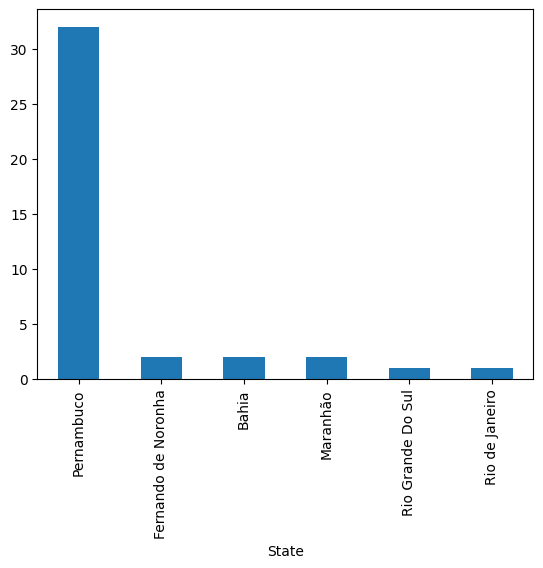

In [69]:
df_brazil_surf['State'].value_counts().plot(kind='bar')

Shark attacks are highly concentrated in Pernambuco, suggesting that risk is location-specific rather than country-wide.

<Axes: xlabel='Activity_group'>

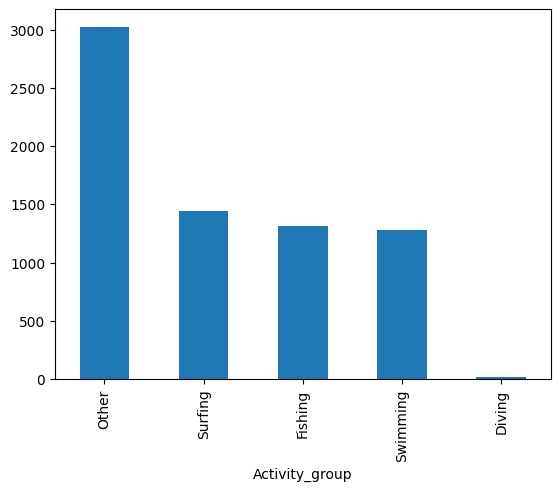

In [70]:
df['Activity_group'].value_counts().plot(kind='bar')

While Brazil is a viable location for a surf school, risk is not evenly distributed. By avoiding high-risk areas like Pernambuco and operating during lower-risk months, it is possible to build a safer surf experience